# Day 08. Exercise 05
# Clustering

## 0. Imports

In [132]:
import pandas as pd
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
import numpy as np

## 1. Preprocessing

1. Read the file [`regression.csv`](https://drive.google.com/file/d/1fzOPkuXoxLleOsvNVCT0m-LKxlid33ma/view?usp=sharing) to a dataframe.
2. Remove the `pageviews`, we will cluster the users only by the number of the commits and their average difference.

In [133]:
df = pd.read_csv('../data/regression.csv').drop(columns='pageviews')
df.head()

,uid,num_commits,AVG(diff)
0,user_1,62,-64.400000
1,user_10,20,-74.800000
2,user_14,61,-159.000000
3,user_17,51,-61.600000
4,user_18,5,-5.666667


## 2. KMeans

1. Check the documentation about how this algorithm works.
2. Use this algorithm to create clusters, use `random_state=21` and `n_clusters=3`.
3. Visualize the data on a `scatter plot`.
4. Try different values of `n_clusters` and see how your plot will change.
5. Calculate the `silhouette_score` (check the docs about the metric).

In [134]:
X = df.drop(columns='uid')
y = df['uid']

In [135]:
kmeans = KMeans(n_clusters=3, random_state=21)
labels = kmeans.fit_predict(X)

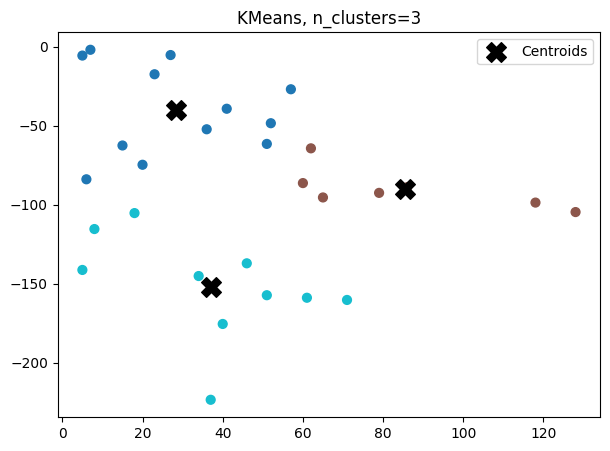

In [136]:
plt.figure(figsize=(7, 5))
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=labels, cmap='tab10', s=40)
plt.scatter(kmeans.cluster_centers_[:, 0],
            kmeans.cluster_centers_[:, 1],
            marker='X', s=200, c='black', label='Centroids'
           )
plt.title('KMeans, n_clusters=3')
plt.legend()
plt.show()

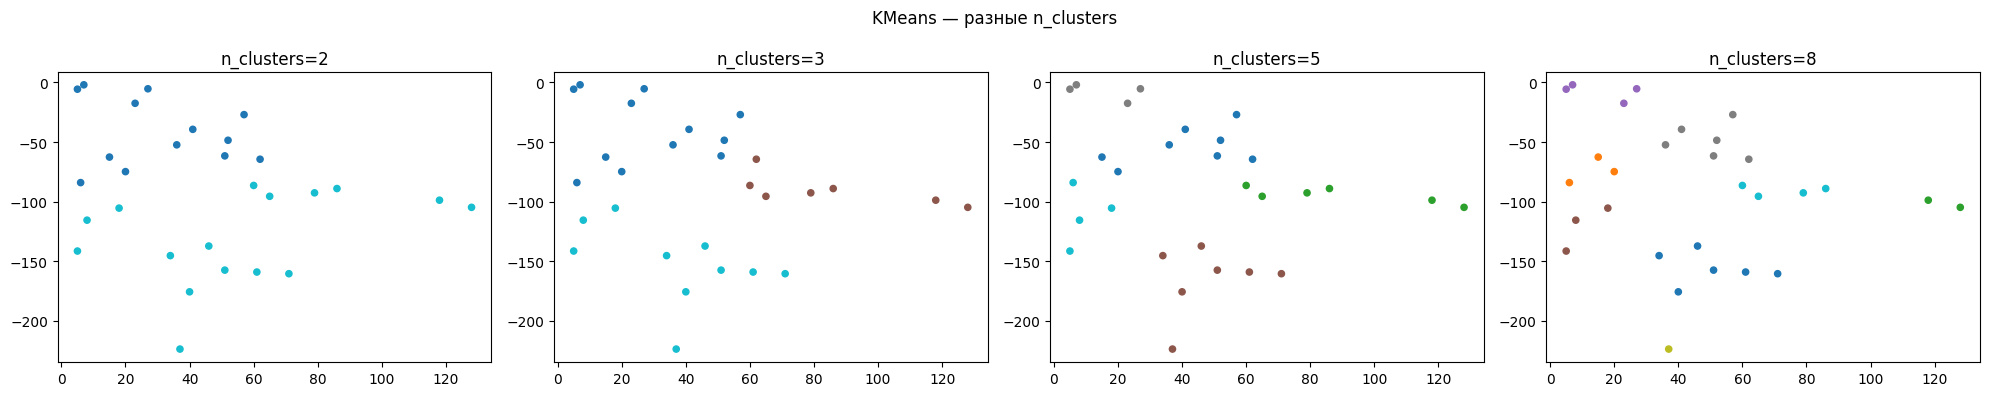

In [137]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, k in zip(axes, [2, 3, 5, 8]):
    lbl = KMeans(n_clusters=k, random_state=21).fit_predict(X)
    ax.scatter(X.iloc[:, 0], X.iloc[:, 1], c=lbl, cmap='tab10', s=20)
    ax.set_title(f'n_clusters={k}')
plt.suptitle('KMeans — разные n_clusters')
plt.tight_layout()
plt.show()

In [138]:
print(silhouette_score(X, labels))

0.43901709571532954


## 3. DBSCAN

1. Check the documentation about how this algorithm works.
2. Use this algorithm to create clusters with `eps=20` and `min_samples=2`.
3. Visualize the data on a `scatter plot`.
4. Try different values of `eps` and `min_samples` and see how your plot will change.
5. Calculate the `silhouette_score` (check the docs about the metric).

In [139]:
dbscan = DBSCAN(eps=20, min_samples=2)
labels_db = dbscan.fit_predict(X)

In [140]:
n_clusters_found = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise = (labels_db == -1).sum()

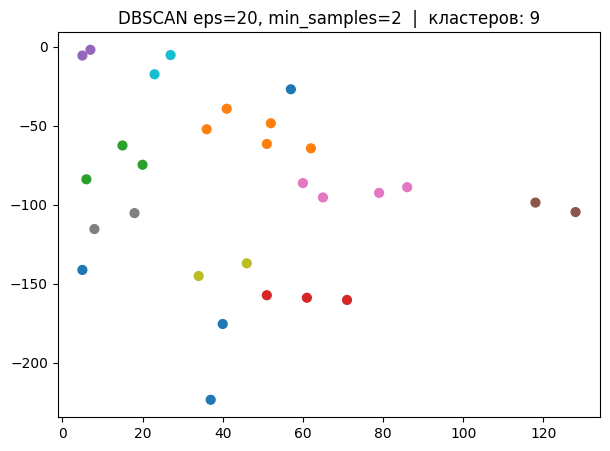

In [141]:
plt.figure(figsize=(7, 5))
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=labels_db, cmap='tab10', s=40)
plt.title(f'DBSCAN eps=20, min_samples=2  |  кластеров: {n_clusters_found}')
plt.show()

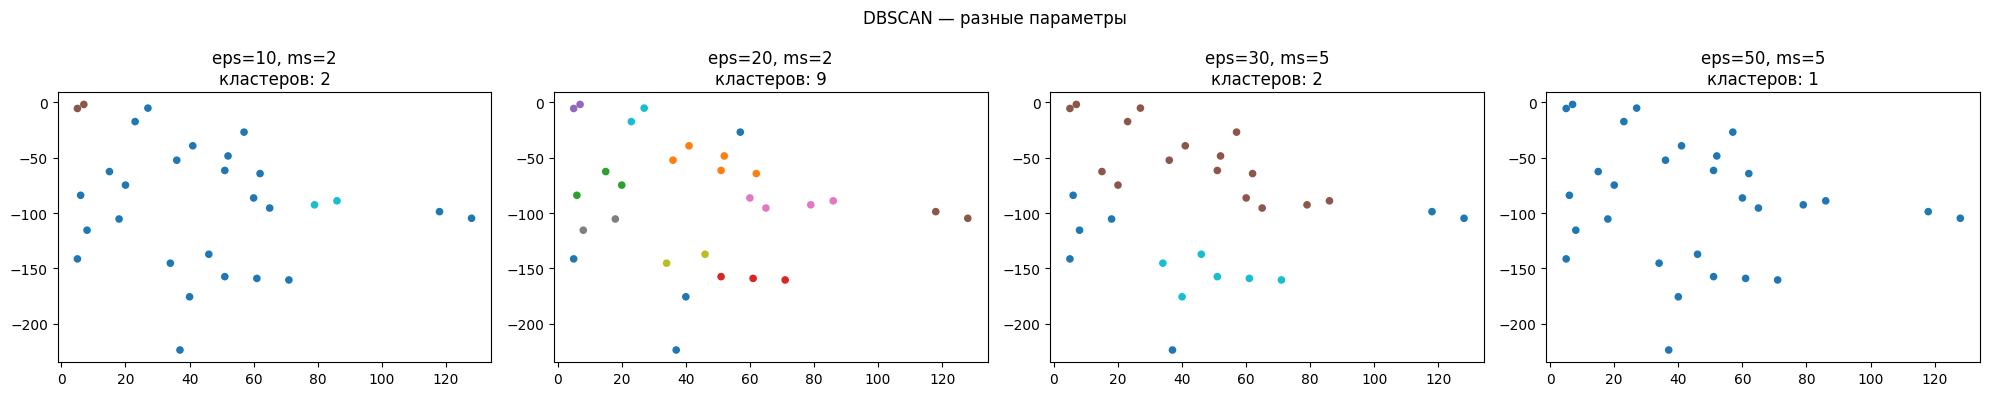

In [142]:
params = [(10, 2), (20, 2), (30, 5), (50, 5)]
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, (eps, ms) in zip(axes, params):
    lbl = DBSCAN(eps=eps, min_samples=ms).fit_predict(X)
    ax.scatter(X.iloc[:, 0], X.iloc[:, 1], c=lbl, cmap='tab10', s=20)
    k = len(set(lbl)) - (1 if -1 in lbl else 0)
    ax.set_title(f'eps={eps}, ms={ms}\nкластеров: {k}')
plt.suptitle('DBSCAN — разные параметры')
plt.tight_layout()
plt.show()

In [143]:
mask = labels_db != -1
print(silhouette_score(X[mask], labels_db[mask]))

0.5441859666389783


## 4. Hierarchical (AgglomerativeClustering)

1. Use this algorithm to create clusters with `n_clusters=5`.
2. Visualize the data on a `scatter plot`.
3. Try different values of `n_clusters` and see how your plot will change.
4. Calculate the `silhouette_score`.
5. Visualize the `dendrogram`.

In [144]:
agg = AgglomerativeClustering(n_clusters=5)
labels_agg = agg.fit_predict(X)

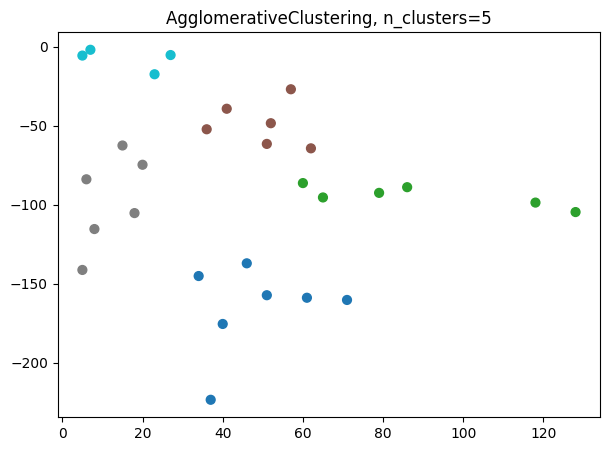

In [145]:
plt.figure(figsize=(7, 5))
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=labels_agg, cmap='tab10', s=40)
plt.title('AgglomerativeClustering, n_clusters=5')
plt.show()

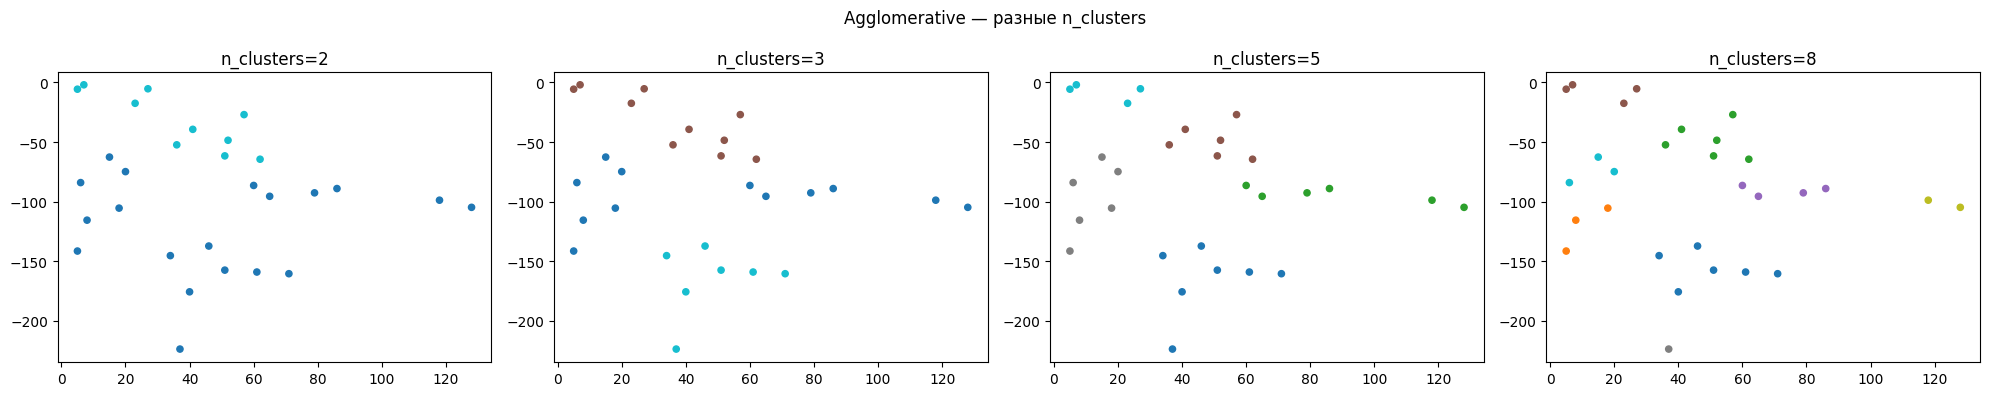

In [146]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, k in zip(axes, [2, 3, 5, 8]):
    lbl = AgglomerativeClustering(n_clusters=k).fit_predict(X)
    ax.scatter(X.iloc[:, 0], X.iloc[:, 1], c=lbl, cmap='tab10', s=20)
    ax.set_title(f'n_clusters={k}')
plt.suptitle('Agglomerative — разные n_clusters')
plt.tight_layout()
plt.show()

In [147]:
print(silhouette_score(X, labels_agg))

0.46383015199381467


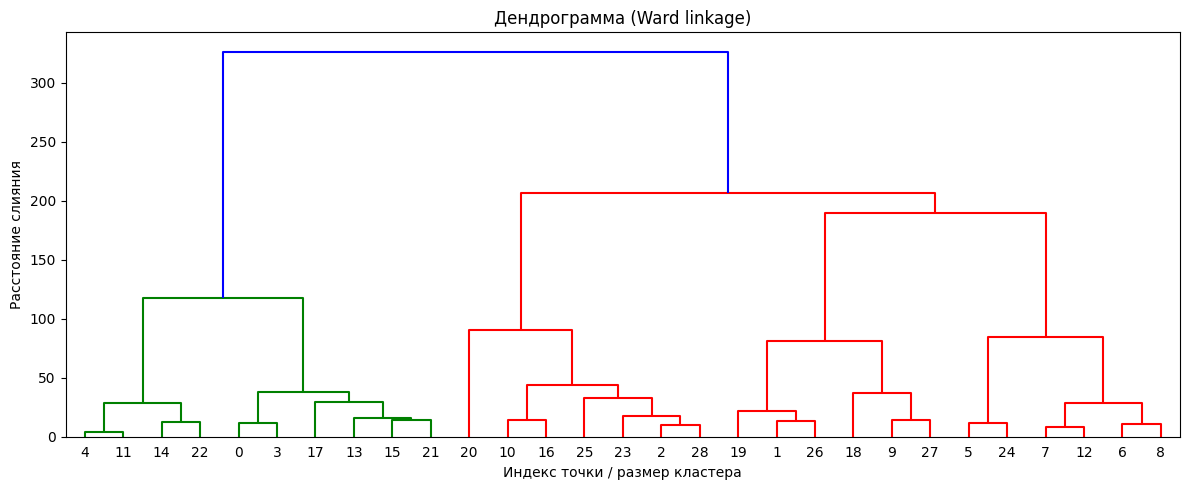

In [148]:
Z = linkage(X, method='ward')

plt.figure(figsize=(12, 5))
dendrogram(Z, truncate_mode='lastp', p=30,
           leaf_rotation=0, leaf_font_size=10
          )
plt.title('Дендрограмма (Ward linkage)')
plt.xlabel('Индекс точки / размер кластера')
plt.ylabel('Расстояние слияния')
plt.tight_layout()
plt.show()

## 5. Function

Write a function that:
1. Takes as arguments: model class of clustering, its parameters, the name of the parameter for optimization, the range of the parameter values to try.
2. Tries different values from the given parameter range and calculates the `silhouette_score` for each value from the range.
3. Finds out the best value for the parameter in the range.
4. Returns two subplots:


- - the first shows how the `silhouette_score` changes depending on the value of the parameter,
- - the second visualizes the data on a `scatter plot` using the clustering model with the best value of the parameter.

In [149]:
def optimize_clustering(model_class, model_params, param_name, param_range):
    """
    model_class — класс модели (KMeans, DBSCAN, AgglomerativeClustering)
    model_params — базовые параметры (dict) {'random_state': 21}
    param_name — оптимизируемый параметр ('n_clusters')
    param_range— список значений для перебора range(2, 10)
    """
    scores = []
    best_score = -1
    best_labels = None
    best_value = None

    for val in param_range:
        params = {**model_params, param_name: val}
        model = model_class(**params)
        labels = model.fit_predict(X)

        unique = set(labels) - {-1}
        if len(unique) < 2:
            scores.append(np.nan)
            continue

        mask = labels != -1
        score = silhouette_score(X.iloc[mask], labels[mask])
        scores.append(score)

        if score > best_score:
            best_score = score
            best_labels = labels.copy()
            best_value = val

    _, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(list(param_range), scores, marker='o', color='steelblue')
    ax1.axvline(best_value, color='red', linestyle='--',
                label=f'best {param_name}={best_value}\nscore={best_score:.4f}')
    ax1.set_xlabel(param_name)
    ax1.set_ylabel('Silhouette Score')
    ax1.set_title(f'Silhouette vs {param_name}')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    scatter = ax2.scatter(X.iloc[:, 0], X.iloc[:, 1], c=best_labels, cmap='tab10', s=40)
    ax2.set_title(f'{model_class.__name__}  |  {param_name}={best_value}')
    plt.colorbar(scatter, ax=ax2, label='Cluster')

    plt.suptitle(f'Оптимизация {param_name} для {model_class.__name__}', fontsize=13)
    plt.tight_layout()
    plt.show()

    return best_value

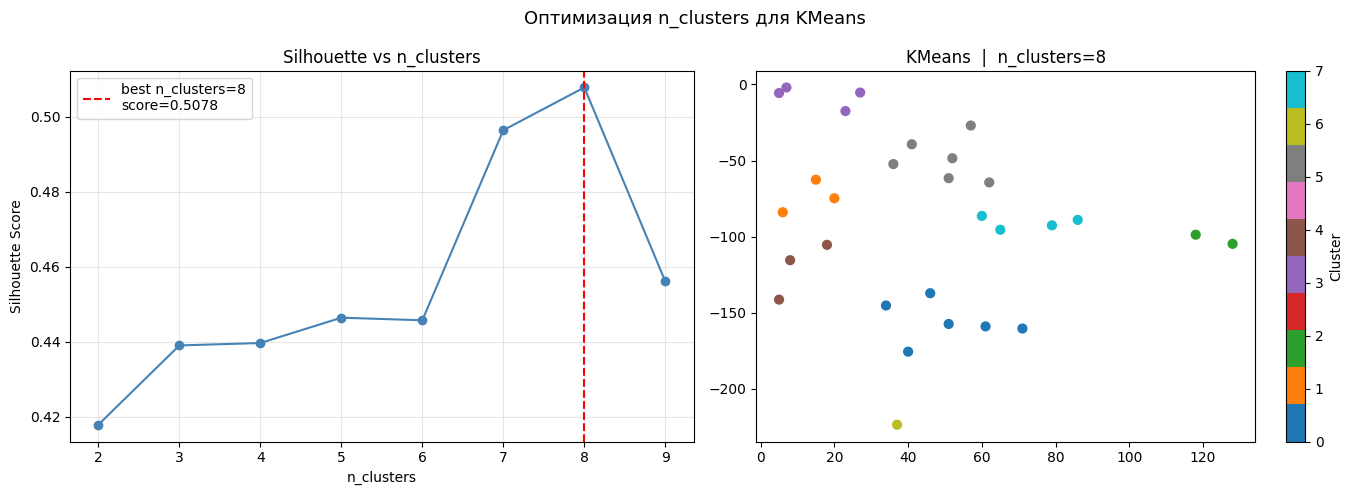

8

In [150]:
optimize_clustering(KMeans, {'random_state': 21}, 'n_clusters', range(2, 10))

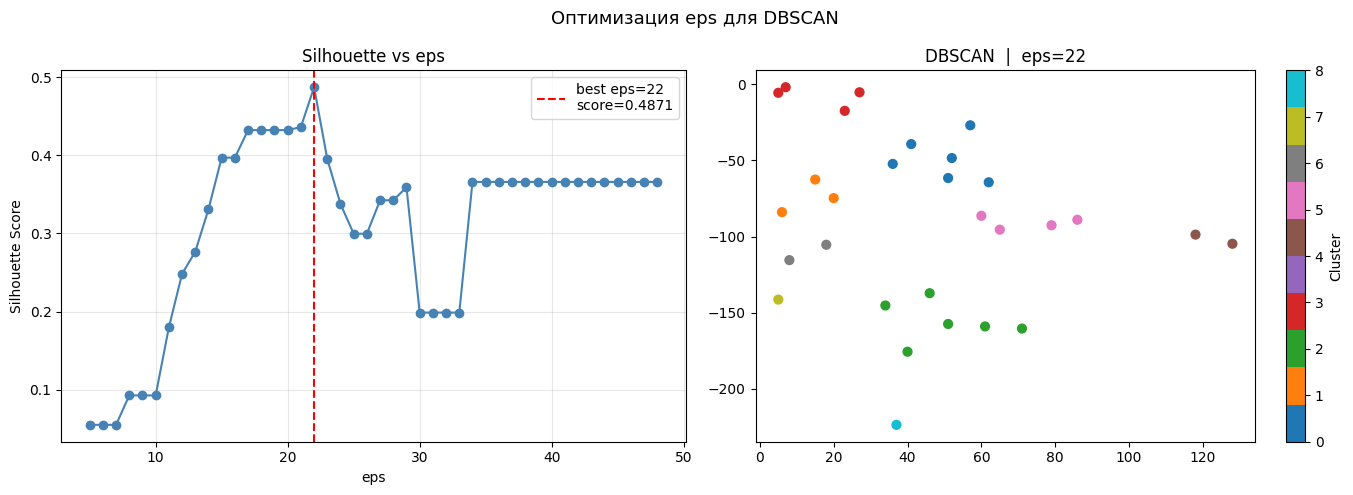

22

In [151]:
optimize_clustering(DBSCAN, {'min_samples': 1}, 'eps', range(5, 60, 1))

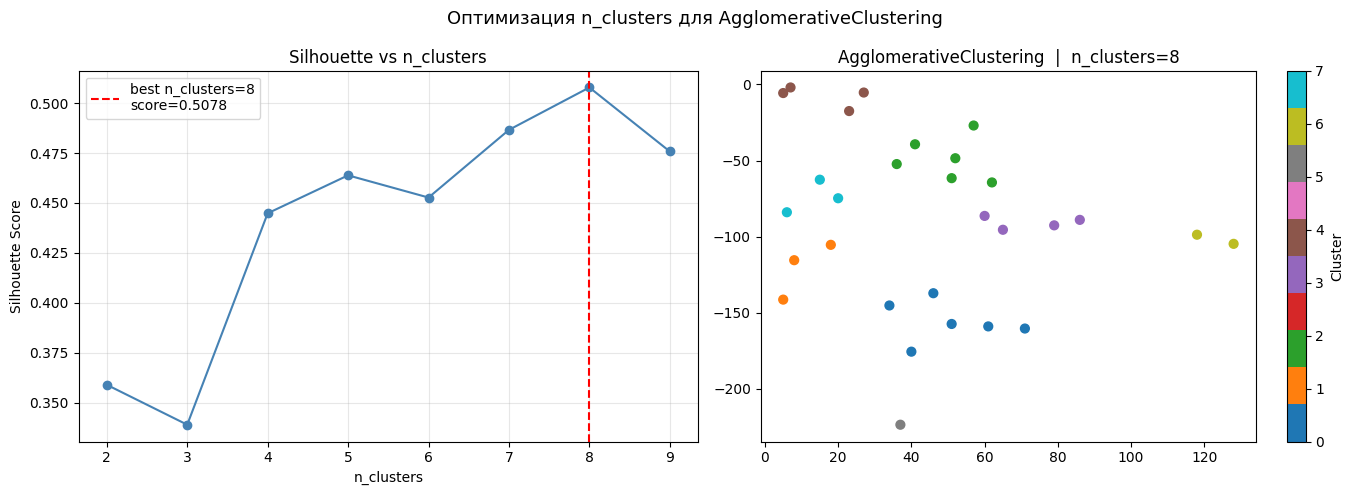

8

In [152]:
optimize_clustering(AgglomerativeClustering, {}, 'n_clusters', range(2, 10))